# ITC6110 — NLP Group Project
## Notebook 1: Data Collection, EDA, Preprocessing & Feature Engineering

**Steps covered:** 1 (Data Collection), 2 (Preprocessing & Normalisation), 3 (Feature Engineering & Visualisation)

**Dataset:** BBC News — 2,225 articles across 5 categories (sport, business, politics, tech, entertainment)

---
## Colab Setup *(skip this cell if running locally)*

Run this cell first when opening in Google Colab. It clones the repo, installs
packages, and changes to the correct working directory.

In [ ]:
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    REPO = '/content/itc6110-nlp-project'

    # Clone repo if not already present
    if not os.path.exists(REPO):
        os.system(f'git clone https://github.com/Geoanto8043/itc6110-nlp-project {REPO}')
        print("Repo cloned.")
    else:
        os.system(f'git -C {REPO} pull')
        print("Repo updated.")

    # Install packages (torch already available on Colab)
    os.system('pip install -q datasets gensim pyldavis wordcloud '
              'sentence-transformers faiss-cpu lime shap '
              'evaluate rouge_score accelerate transformers')
    print("Packages installed.")

    # Change to notebooks directory so relative paths (../data/) work
    os.chdir(f'{REPO}/notebooks')
    print(f"Working directory: {os.getcwd()}")

    # Optional: mount Google Drive to persist models between sessions
    # from google.colab import drive
    # drive.mount('/content/drive')
    # Then save models to /content/drive/MyDrive/nlp_project/models/
else:
    print("Running locally — Colab setup skipped.")
    print(f"Working directory: {os.getcwd()}")

---
## 0. Device Check

This notebook is **CPU-only** — preprocessing, TF-IDF, Gensim Word2Vec and t-SNE all run on the CPU.
The MPS GPU is used in **Notebook 3** for LSTM training, DistilBERT fine-tuning, and sentence-transformers inference.

We confirm MPS availability here so the environment is verified at the start of every session.

In [1]:
import torch

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print(f"MPS GPU available — PyTorch {torch.__version__} on Apple Silicon")
    # Quick sanity check
    _ = torch.ones(1, device=DEVICE)
    print(f"MPS tensor test passed: device = {DEVICE}")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"CUDA GPU available: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device("cpu")
    print("No GPU detected — running on CPU")

# This variable is imported by Notebook 3
print(f"\nActive device for DL notebooks: {DEVICE}")
print("Notebook 1 itself uses CPU for all operations (correct).")

MPS GPU available — PyTorch 2.12.1 on Apple Silicon
MPS tensor test passed: device = mps

Active device for DL notebooks: mps
Notebook 1 itself uses CPU for all operations (correct).


---
## 1. Imports & Configuration

In [2]:
import os, re, string, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import Counter
from pathlib import Path

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Embeddings
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from gensim.models import Word2Vec

# Visualisation
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from wordcloud import WordCloud

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

# Download required NLTK data (run once)
for pkg in ['punkt', 'stopwords', 'wordnet', 'omw-1.4', 'punkt_tab']:
    nltk.download(pkg, quiet=True)

SEED = 42
np.random.seed(SEED)
print("Imports OK")

Imports OK


---
## 2. Data Loading & Initial Exploration (Step 1)

In [3]:
# Load dataset saved from HuggingFace
DATA_PATH = Path('../data/raw/bbc_news.csv')
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Shape: (2225, 4)
Columns: ['text', 'category', 'label_id', 'split']


,text,category,label_id,split
0,wales want rugby league training wales could f...,sport,2,train
1,china aviation seeks rescue deal scandal-hit j...,business,1,train
2,rock band u2 break ticket record u2 have smash...,entertainment,3,train


In [ ]:
# Basic info — dtypes, nulls and dup check before we touch anything
print("=== Dataset Info ===")
print(df.info())                                    # column dtypes + non-null counts
print("\n=== Missing Values ===")
print(df.isnull().sum())                            # any empty fields?
print("\n=== Duplicates ===")
print(f"Duplicate rows: {df.duplicated().sum()}")   # exact-row dupes (dropped next)

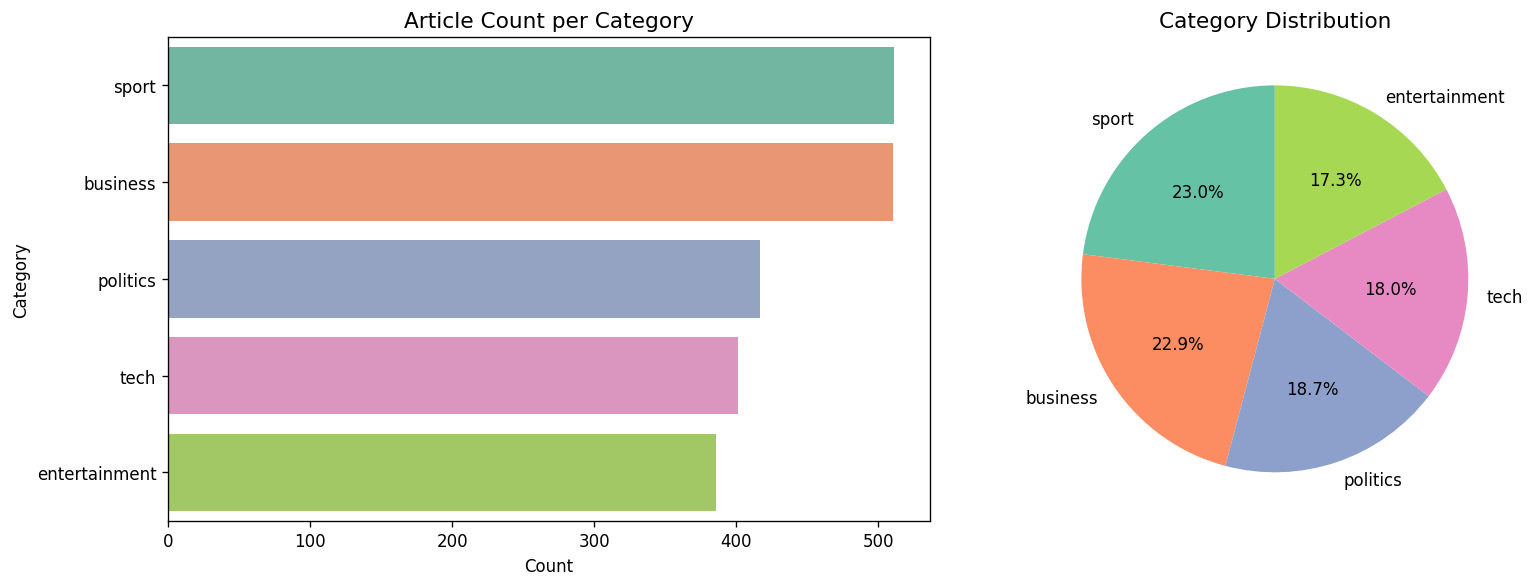

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64


In [5]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
order = df['category'].value_counts().index
sns.countplot(data=df, y='category', order=order, palette='Set2', ax=axes[0])
axes[0].set_title('Article Count per Category', fontsize=13)
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Category')

# Pie chart
counts = df['category'].value_counts()
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(counts)), startangle=90)
axes[1].set_title('Category Distribution', fontsize=13)

plt.tight_layout()
plt.savefig('../outputs/figures/01_class_distribution.png', bbox_inches='tight')
plt.show()
print(counts)

In [ ]:
# Article length analysis
df['char_len'] = df['text'].str.len()                # chars per article
df['word_count'] = df['text'].str.split().str.len()  # words per article

print("=== Article Length Statistics ===")
print(df[['char_len', 'word_count']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: boxplot — length spread per category, quick way to spot skew/outliers
sns.boxplot(data=df, x='category', y='word_count', palette='Set2', ax=axes[0])
axes[0].set_title('Word Count Distribution by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Word Count')
axes[0].tick_params(axis='x', rotation=15)

# right: histogram — overall length distribution, coloured by category
sns.histplot(data=df, x='word_count', hue='category', bins=40,
             palette='Set2', alpha=0.6, ax=axes[1])
axes[1].set_title('Word Count Histogram by Category')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('../outputs/figures/02_article_lengths.png', bbox_inches='tight')
plt.show()

---
## 3. Data Preprocessing & Normalisation (Step 2)

All steps are justified below each cell.

In [7]:
# ── Step 2a: Remove duplicates and missing values ────────────────────────────
initial_len = len(df)
df = df.drop_duplicates(subset='text').dropna(subset=['text', 'category'])
print(f"Removed {initial_len - len(df)} duplicate/null rows. Remaining: {len(df)}")

Removed 99 duplicate/null rows. Remaining: 2126


In [8]:
# ── Step 2b: Preprocessing pipeline ─────────────────────────────────────────
#
# Justification:
#  - Lowercase: standardises token matching
#  - URL/HTML removal: these carry no semantic signal for topic classification
#  - Contraction expansion: ensures 'don't' and 'do not' map to same tokens
#  - Punctuation/special char removal: reduces noise in bag-of-words models
#  - Stopword removal: high-frequency function words obscure topic signal
#  - Lemmatisation: preferred over stemming here because it produces valid
#    English words (better for Word2Vec training and human readability in LDA)
#  - Tokenisation: required for all downstream embedding methods

CONTRACTIONS = {
    "n't": " not", "'re": " are", "'s": " is", "'d": " would",
    "'ll": " will", "'t": " not", "'ve": " have", "'m": " am",
    "can't": "cannot", "won't": "will not",
}

STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def expand_contractions(text):
    for k, v in CONTRACTIONS.items():
        text = text.replace(k, v)
    return text

def clean_text(text):
    text = text.lower()                                        # lowercase
    text = re.sub(r'http\S+|www\.\S+', '', text)          # remove URLs
    text = re.sub(r'<[^>]+>', '', text)                       # remove HTML tags
    text = expand_contractions(text)                          # expand contractions
    text = re.sub(r'[^a-z\s]', ' ', text)                   # keep only letters + spaces
    text = re.sub(r'\s+', ' ', text).strip()                 # normalise whitespace
    return text

def lemmatize_and_filter(text):
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t) > 2]
    return tokens

# Apply pipeline
print("Cleaning text...")
df['text_clean'] = df['text'].apply(clean_text)

print("Tokenising and lemmatising...")
df['tokens'] = df['text_clean'].apply(lemmatize_and_filter)
df['text_processed'] = df['tokens'].apply(lambda t: ' '.join(t))

print("Done.")
df[['text', 'text_processed', 'category']].head(3)

Cleaning text...
Tokenising and lemmatising...
Done.


,text,text_processed,category
0,wales want rugby league training wales could f...,wale want rugby league training wale could fol...,sport
1,china aviation seeks rescue deal scandal-hit j...,china aviation seek rescue deal scandal hit je...,business
2,rock band u2 break ticket record u2 have smash...,rock band break ticket record smashed irish bo...,entertainment


Vocabulary size (raw):        27,905
Vocabulary size (processed):  24,560
Reduction:                    12.0%


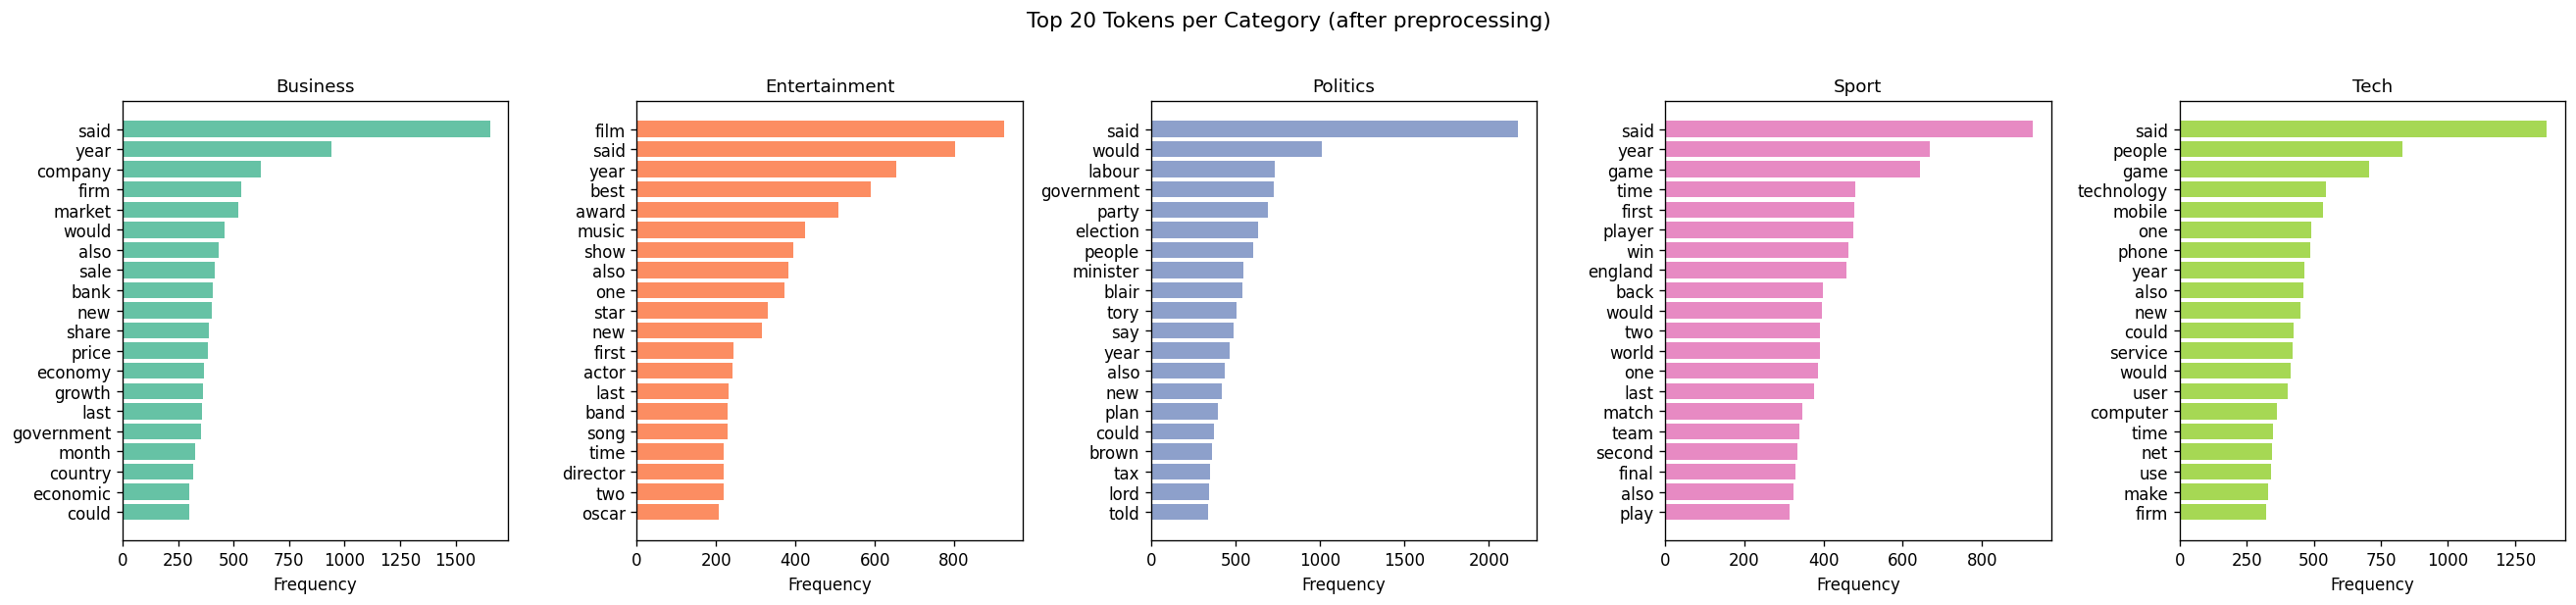

In [9]:
# Vocabulary analysis before and after preprocessing
raw_vocab = set(' '.join(df['text_clean']).split())
proc_vocab = set(' '.join(df['text_processed']).split())

print(f"Vocabulary size (raw):        {len(raw_vocab):,}")
print(f"Vocabulary size (processed):  {len(proc_vocab):,}")
print(f"Reduction:                    {(1 - len(proc_vocab)/len(raw_vocab))*100:.1f}%")

# Top 20 tokens per category
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
categories = df['category'].unique()
palette = sns.color_palette('Set2', 5)

for ax, cat, col in zip(axes, sorted(categories), palette):
    cat_tokens = [t for tokens in df[df['category']==cat]['tokens'] for t in tokens]
    top20 = Counter(cat_tokens).most_common(20)
    words, counts = zip(*top20)
    ax.barh(list(reversed(words)), list(reversed(counts)), color=col)
    ax.set_title(cat.capitalize(), fontsize=11)
    ax.set_xlabel('Frequency')

plt.suptitle('Top 20 Tokens per Category (after preprocessing)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/03_top_tokens_per_category.png', bbox_inches='tight')
plt.show()

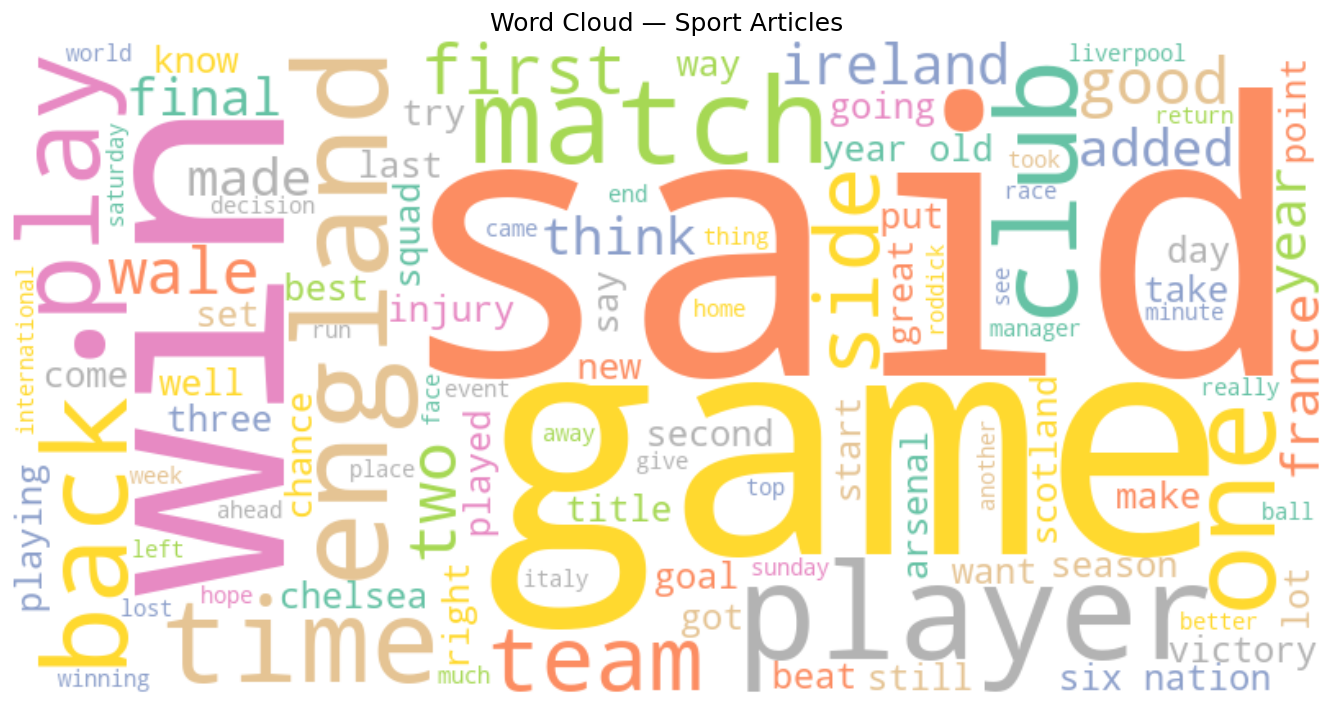

In [10]:
# Word cloud for SPORT category
sport_text = ' '.join(df[df['category'] == 'sport']['text_processed'])
wc = WordCloud(width=800, height=400, background_color='white',
               colormap='Set2', max_words=100).generate(sport_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Sport Articles', fontsize=15)
plt.tight_layout()
plt.savefig('../outputs/figures/04_wordcloud_sport.png', bbox_inches='tight')
plt.show()

In [11]:
# Save processed dataset
PROC_PATH = Path('../data/processed/bbc_news_processed.csv')
df.to_csv(PROC_PATH, index=False)
print(f"Saved processed dataset: {PROC_PATH}  ({len(df)} rows)")

Saved processed dataset: ../data/processed/bbc_news_processed.csv  (2126 rows)


---
## 4. Feature Engineering — Embeddings (Step 3)

### 4.1 TF-IDF

In [12]:
# TF-IDF vectorisation
# Justification: TF-IDF is the standard input for traditional ML classifiers
# (Notebook 2). It down-weights tokens common across all documents while
# highlighting those distinctive to individual articles.

tfidf = TfidfVectorizer(max_features=10_000, ngram_range=(1, 2), min_df=2)
X_tfidf = tfidf.fit_transform(df['text_processed'])

print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Features (sample): {tfidf.get_feature_names_out()[:20]}")

TF-IDF matrix shape: (2126, 10000)
Features (sample): ['aaa' 'aaa title' 'abandoned' 'abba' 'abbas' 'abbasi' 'abbott' 'abc'
 'abiding' 'ability' 'able' 'able access' 'able get' 'able make'
 'able play' 'abn' 'abn amro' 'abolish' 'abortion' 'abroad']


### 4.2 Word2Vec Embeddings

In [13]:
# Train Word2Vec on the full corpus
# Justification: Word2Vec captures semantic relationships between words,
# unlike TF-IDF which treats words as independent features.
# We use Skip-gram (sg=1) as it performs better on smaller corpora.

sentences = df['tokens'].tolist()

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,           # Skip-gram
    workers=4,
    epochs=10,
    seed=SEED,
)

print(f"Vocabulary size: {len(w2v_model.wv):,}")
w2v_model.save('../models/word2vec_bbc.model')
print("Word2Vec model saved.")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulary size: 15,986
Word2Vec model saved.


### 4.3 Top-N Similar Words

In [14]:
# Function: given a word, return N most similar words from the corpus
def get_similar_words(word, n=10):
    """Return the N most similar words to `word` using Word2Vec cosine similarity."""
    if word not in w2v_model.wv:
        return f"'{word}' not in vocabulary."
    similar = w2v_model.wv.most_similar(word, topn=n)
    return pd.DataFrame(similar, columns=['word', 'similarity']).round(4)

# Demonstrate on sport-relevant terms
for query in ['football', 'champion', 'injury', 'transfer', 'olympic']:
    print(f"\n── Most similar to '{query}' ──")
    print(get_similar_words(query, n=8).to_string(index=False))


── Most similar to 'football' ──
       word  similarity
 corinthian      0.6853
     league      0.6853
      ibrox      0.6810
       club      0.6765
       judo      0.6746
     punish      0.6666
sponsorship      0.6659
    anfield      0.6600

── Most similar to 'champion' ──
      word  similarity
     henin      0.7934
   yelling      0.7900
   maurice      0.7890
  hardenne      0.7886
compatriot      0.7880
 wimbledon      0.7872
  kenenisa      0.7866
    hayley      0.7761

── Most similar to 'injury' ──
     word  similarity
     knee      0.7841
hamstring      0.7794
     neck      0.7296
    groin      0.7296
  surgery      0.7202
 shoulder      0.7188
    ankle      0.7174
 ligament      0.7170

── Most similar to 'transfer' ──
       word  similarity
       lure      0.7460
  construed      0.7281
     worded      0.7136
      smart      0.6981
  celestine      0.6970
        edu      0.6932
  morientes      0.6927
sponsorship      0.6859

── Most similar to 'olympic'

In [15]:
# Document-level embeddings: average Word2Vec vectors per article
def doc_vector(tokens):
    vecs = [w2v_model.wv[t] for t in tokens if t in w2v_model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(w2v_model.vector_size)

print("Building document vectors...")
doc_vecs = np.vstack(df['tokens'].apply(doc_vector))
print(f"Document vector matrix: {doc_vecs.shape}")

Building document vectors...
Document vector matrix: (2126, 100)


---
## 5. Text Embedding Visualisation — t-SNE (Step 3)

In [16]:
# t-SNE on Word2Vec document vectors
# t-SNE (t-distributed Stochastic Neighbour Embedding) reduces high-dimensional
# embeddings to 2D for visualisation while preserving local structure.
# We use perplexity=30 (standard for ~2k samples), Barnes-Hut for speed.
# Note: sklearn 1.2+ renamed n_iter → max_iter (removed in 1.8).
# t-SNE has no MPS backend — all CPU cores via n_jobs=-1 is the fast path.

print("Running t-SNE on Word2Vec document vectors (this may take ~60s)...")
tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,        # n_iter removed in sklearn 1.2+
    method="barnes_hut",  # O(N log N) — fast approximation
    n_jobs=-1,            # use all CPU cores
    random_state=SEED,
)
tsne_vecs = tsne.fit_transform(doc_vecs)

tsne_df = pd.DataFrame(tsne_vecs, columns=['x', 'y'])
tsne_df['category'] = df['category'].values

print("Done.")
tsne_df.head(3)

Running t-SNE on Word2Vec document vectors (this may take ~60s)...
Done.


,x,y,category
0,47.615681,17.980865,sport
1,-41.211617,9.376010,business
2,11.477566,-13.137955,entertainment


In [ ]:
# Plot t-SNE coloured by category
# fixed colour per category so every figure in the report shares the same key
palette = {
    'sport': '#2ecc71', 'business': '#3498db',
    'politics': '#e74c3c', 'tech': '#9b59b6', 'entertainment': '#f39c12'
}

fig, ax = plt.subplots(figsize=(12, 8))
# plot one category at a time so each gets its own colour + legend entry
for cat, grp in tsne_df.groupby('category'):
    ax.scatter(grp['x'], grp['y'], label=cat, alpha=0.55, s=18,
               c=palette[cat], edgecolors='none')

ax.set_title('t-SNE of BBC News Articles\n(Word2Vec document embeddings, coloured by category)',
             fontsize=13)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(title='Category', markerscale=2)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('../outputs/figures/05_tsne_w2v.png', bbox_inches='tight')
plt.show()

In [ ]:
# (Optional extra) t-SNE on TF-IDF — compare vs Word2Vec
from sklearn.preprocessing import normalize

print("Running t-SNE on TF-IDF matrix (SVD reduction first)...")
from sklearn.decomposition import TruncatedSVD

# t-SNE can't handle 10k sparse dims directly — squash to 50 dense dims first
svd = TruncatedSVD(n_components=50, random_state=SEED)
X_svd = svd.fit_transform(X_tfidf)

tsne2 = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
tsne2_vecs = tsne2.fit_transform(X_svd)

tsne2_df = pd.DataFrame(tsne2_vecs, columns=['x', 'y'])
tsne2_df['category'] = df['category'].values

# side by side: Word2Vec vs TF-IDF, same colour key, to compare separation
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (title, data) in zip(axes, [
    ('t-SNE — Word2Vec Embeddings', tsne_df),
    ('t-SNE — TF-IDF (via SVD)', tsne2_df),
]):
    for cat, grp in data.groupby('category'):
        ax.scatter(grp['x'], grp['y'], label=cat, alpha=0.5, s=15,
                   c=palette[cat], edgecolors='none')
    ax.set_title(title, fontsize=12)
    ax.legend(title='Category', markerscale=2, fontsize=8)
    ax.grid(alpha=0.2)

plt.suptitle('Embedding Comparison: Word2Vec vs TF-IDF', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/06_tsne_comparison.png', bbox_inches='tight')
plt.show()
print("Observation: discuss which embedding shows clearer cluster separation and why.")

---
## 6. Save Artefacts for Notebook 2

In [19]:
import pickle

# Save TF-IDF matrix and vectoriser (needed by Notebook 2 for ML classifiers)
with open('../data/processed/tfidf_matrix.pkl', 'wb') as f:
    pickle.dump({'matrix': X_tfidf, 'vectoriser': tfidf, 'labels': df['category'].values}, f)

# Save document vectors (needed by Notebook 2 for LDA and LSTM)
np.save('../data/processed/doc_vectors_w2v.npy', doc_vecs)

# Save the full processed dataframe
df.to_csv('../data/processed/bbc_news_processed.csv', index=False)

print("Artefacts saved:")
print("  data/processed/tfidf_matrix.pkl")
print("  data/processed/doc_vectors_w2v.npy")
print("  data/processed/bbc_news_processed.csv")
print("  models/word2vec_bbc.model")
print("\nNotebook 1 complete — hand off to Notebook 2.")

Artefacts saved:
  data/processed/tfidf_matrix.pkl
  data/processed/doc_vectors_w2v.npy
  data/processed/bbc_news_processed.csv
  models/word2vec_bbc.model

Notebook 1 complete — hand off to Notebook 2.
